<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/LangStudio/RSI_Max_Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [10]:
warnings.filterwarnings("ignore")

# --- 1. Configuration & Symbol Loading ---
# Bearish thresholds (Overbought levels)
RSI_LEVELS = [60, 65, 70, 75, 80]
RSI_LENGTHS = [3, 5, 7, 10, 12, 14, 16, 18, 22, 24, 26]

try:
    # Using your specific filename mentioned in previous turns
    csv_name = "OptionVolume50_20260201.csv"
    df_csv = pd.read_csv(csv_name)
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower() or 'ticker' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from {csv_name}")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT"]

# --- 2. Enhanced RSI Function ---
def calculate_rsi_yahoo(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# --- 3. Data Fetching ---
print("Fetching data and calculating vectorized returns...")
data_cache = {}
for s in SYMBOLS:
    try:
        # auto_adjust=True handles splits/dividends; multi_level=False prevents MultiIndex
        df = yf.download(s, period="5y", interval="1d", progress=False, auto_adjust=True)
        if df.empty: continue

        # Ensure column names are clean
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Vectorized Future Returns (The "Trade" result)
        df['Ret_3D'] = df['Close'].pct_change(3).shift(-3)
        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)
        df['Ret_10D'] = df['Close'].pct_change(10).shift(-10)

        data_cache[s] = df
    except:
        continue

# --- 4. Parameter Sweep ---
all_results = []

for rsi_len in RSI_LENGTHS:
    for rsi_thresh in RSI_LEVELS:
        param_trades = []

        for symbol, df_orig in data_cache.items():
            df = df_orig.copy()
            df['RSI'] = calculate_rsi_yahoo(df['Close'], period=rsi_len)

            # --- UPDATED TRIGGER LOGIC: THE CROSSOVER ---
            # 1. Current RSI is above threshold
            # 2. Previous RSI was below or equal to threshold
            condition = (df['RSI'] > rsi_thresh) & (df['RSI'].shift(1) <= rsi_thresh)

            trades = df[condition].dropna(subset=['Ret_10D']).copy()

            if not trades.empty:
                trades['RSI_Len'] = rsi_len
                trades['RSI_Thresh'] = rsi_thresh
                param_trades.append(trades)

        if param_trades:
            combined = pd.concat(param_trades)
            # BEARISH WIN RATE: A win is when future return is NEGATIVE (< 0)
            all_results.append({
                "RSI_Len": rsi_len,
                "RSI_Thresh": rsi_thresh,
                "Avg_3D_Ret": combined['Ret_3D'].mean(),
                "Avg_5D_Ret": combined['Ret_5D'].mean(),
                "Avg_10D_Ret": combined['Ret_10D'].mean(),
                "Win_Rate_3D": (combined['Ret_3D'] > 0).mean(),
                "Win_Rate_5D": (combined['Ret_5D'] > 0).mean(),
                "Win_Rate_10D": (combined['Ret_10D'] > 0).mean(),
                "Trade_Count": len(combined)
            })

# --- 5. Summary Display ---
if all_results:
    summary_df = pd.DataFrame(all_results)
    # Sorting by Win_Rate_5D to find the best bearish signals
    summary_df = summary_df.sort_values(by="Win_Rate_5D", ascending=False)
    #summary_df = summary_df.sort_values(by="Avg_5D_Ret", ascending=False)

    print("\n--- BEARISH RSI OPTIMIZATION SUMMARY ---")
    display(summary_df)
    summary_df.to_csv("bearish_rsi_results.csv", index=False)
else:
    print("No bearish signals found.")

Loaded 50 symbols from OptionVolume50_20260201.csv
Fetching data and calculating vectorized returns...

--- BEARISH RSI OPTIMIZATION SUMMARY ---


,RSI_Len,RSI_Thresh,Avg_3D_Ret,Avg_5D_Ret,Avg_10D_Ret,Win_Rate_3D,Win_Rate_5D,Win_Rate_10D,Trade_Count
19,10,80,0.017327,0.020971,0.036164,0.594356,0.624339,0.668430,567
28,14,75,0.016961,0.020772,0.034250,0.586314,0.604977,0.650078,643
42,22,70,0.011905,0.017239,0.032821,0.555723,0.597892,0.623494,664
37,18,70,0.010359,0.018057,0.031708,0.565410,0.596452,0.599778,902
47,24,70,0.013836,0.019825,0.030022,0.577320,0.589347,0.599656,582
51,26,65,0.009022,0.013275,0.023939,0.580972,0.589069,0.592105,988
33,16,75,0.012657,0.016139,0.031871,0.565891,0.587209,0.608527,516
14,7,80,0.011215,0.015060,0.032653,0.578207,0.584359,0.625659,1138
23,12,75,0.013441,0.017849,0.032806,0.569395,0.581257,0.623962,843
18,10,75,0.010999,0.015735,0.029356,0.576824,0.580258,0.603433,1165


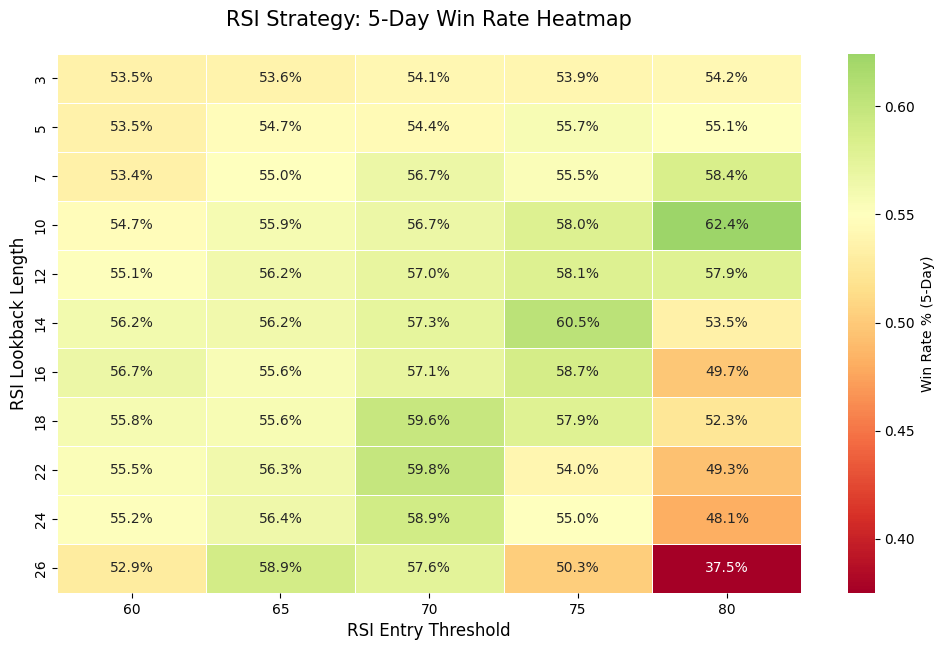

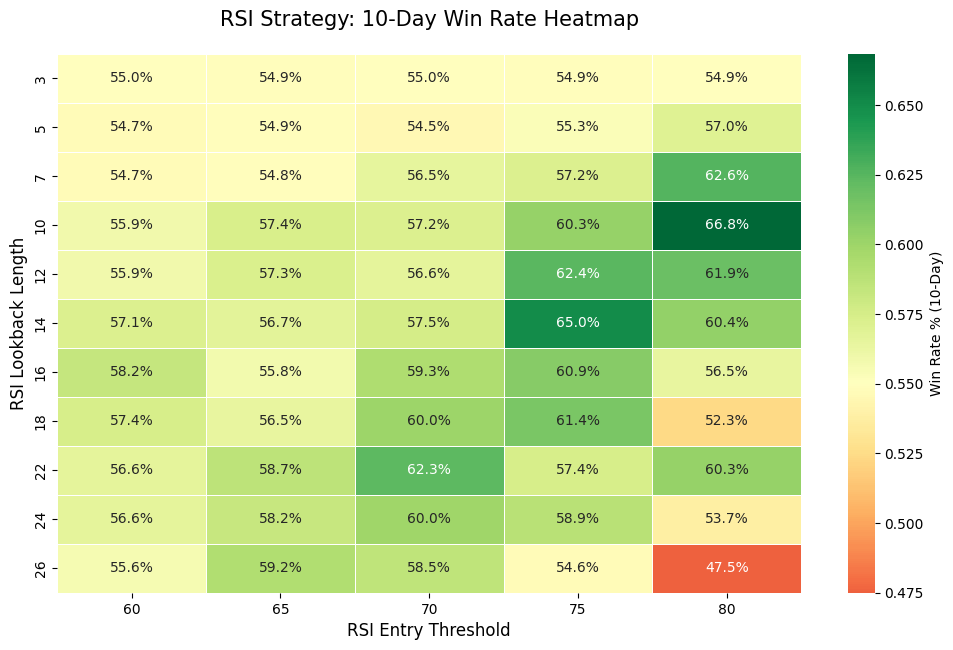

In [11]:
# 1. Pivot the data for 5-Day Win Rate
heatmap_data_5d = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Win_Rate_5D")

# 2. Set up the figure for 5-Day Win Rate Heatmap
plt.figure(figsize=(12, 7))

# 3. Create the heatmap for 5-Day Win Rate
sns.heatmap(
    heatmap_data_5d,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    vmin=summary_df["Win_Rate_5D"].min(),
    vmax=summary_df["Win_Rate_5D"].max(),
    center=0.55,
    linewidths=.5,
    cbar_kws={'label': 'Win Rate % (5-Day)'}
)

# 4. Labels for 5-Day Win Rate Heatmap
plt.title("RSI Strategy: 5-Day Win Rate Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

# --- Separator for 10-Day Win Rate Heatmap ---

# 1. Pivot the data for 10-Day Win Rate
heatmap_data_10d = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Win_Rate_10D")

# 2. Set up the figure for 10-Day Win Rate Heatmap
plt.figure(figsize=(12, 7))

# 3. Create the heatmap for 10-Day Win Rate
sns.heatmap(
    heatmap_data_10d,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    vmin=summary_df["Win_Rate_10D"].min(),
    vmax=summary_df["Win_Rate_10D"].max(),
    center=0.55,
    linewidths=.5,
    cbar_kws={'label': 'Win Rate % (10-Day)'}
)

# 4. Labels for 10-Day Win Rate Heatmap
plt.title("RSI Strategy: 10-Day Win Rate Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

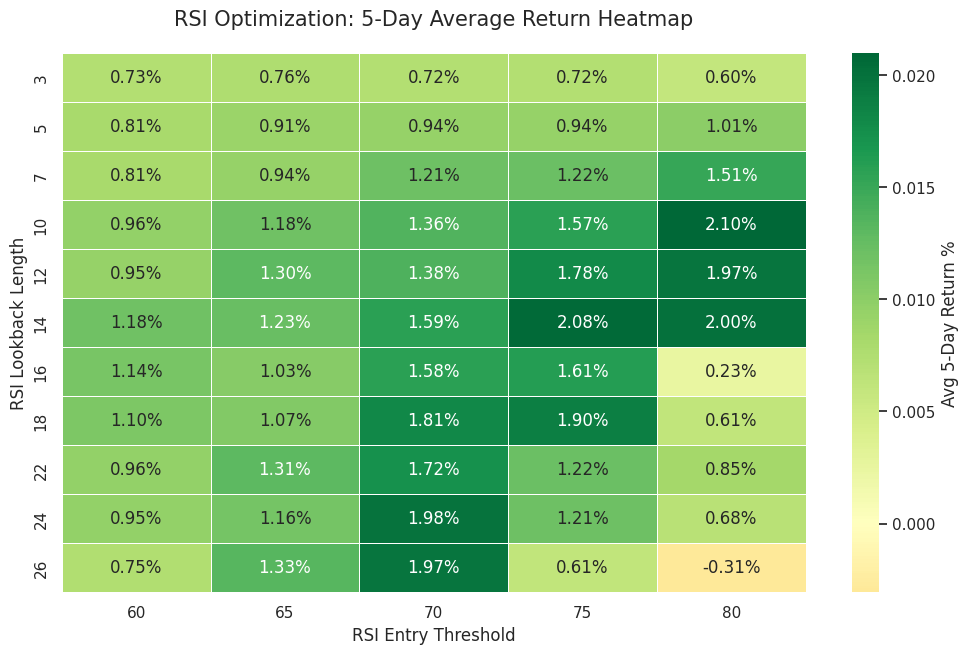

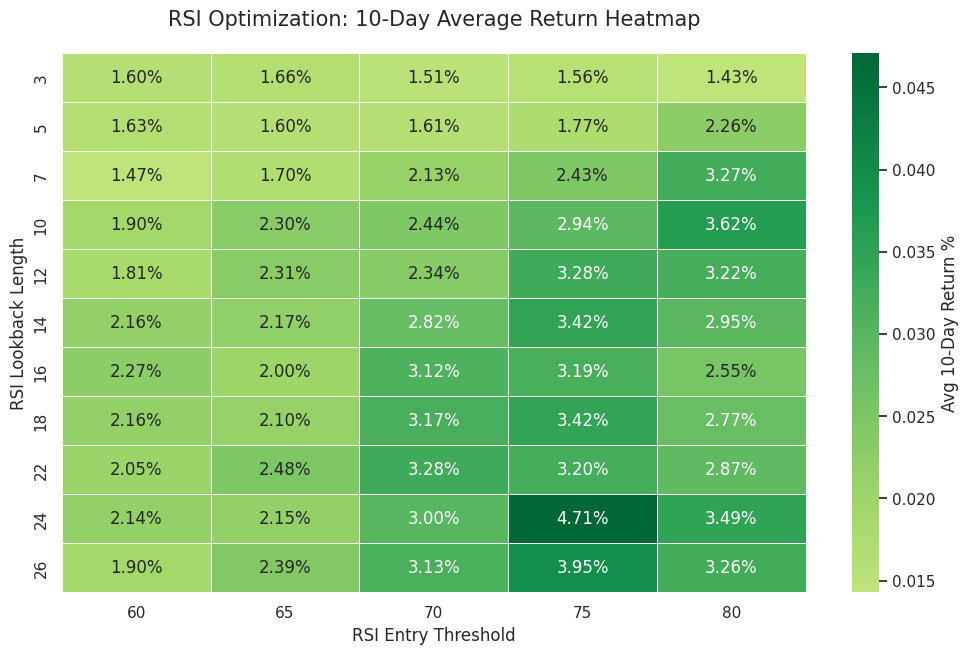

In [14]:
# Average Return Heatmaps
# 1. Pivot the data for Average 5-Day Return
heatmap_data_5d_avg = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Avg_5D_Ret")

# 2. Set up the figure for Average 5-Day Return Heatmap
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

# 3. Create the heatmap with optimized gradient parameters
# vmin/vmax: Stretches the color range to your specific best and worst performers
# center=0: Ensures the color transition happens exactly at the break-even point
sns.heatmap(
    heatmap_data_5d_avg,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    vmin=summary_df["Avg_5D_Ret"].min(),
    vmax=summary_df["Avg_5D_Ret"].max(),
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Avg 5-Day Return %'}
)

# 4. Labels and Title
plt.title("RSI Optimization: 5-Day Average Return Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

# --- Separator for Average 10-Day Return Heatmap ---

# 1. Pivot the data for Average 10-Day Return
heatmap_data_10d_avg = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Avg_10D_Ret")

# 2. Set up the figure for Average 10-Day Return Heatmap
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

# 3. Create the heatmap with optimized gradient parameters
sns.heatmap(
    heatmap_data_10d_avg,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    vmin=summary_df["Avg_10D_Ret"].min(),
    vmax=summary_df["Avg_10D_Ret"].max(),
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Avg 10-Day Return %'}
)

# 4. Labels and Title
plt.title("RSI Optimization: 10-Day Average Return Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()